# Cross-Validation and Model Selection
**Summer of Science 2026 — CS03: Artificial Intelligence and Machine Learning**  
**Mohit Khyalia | IIT Bombay**

---

## Project Overview

Train/validation/test split, K-Fold cross-validation, and a basic hyperparameter search.

Main goals:

- Compare a single train/validation/test split against K-Fold cross-validation.
- Use cross-validation to compare two models on the same data.
- Run a small grid search over a hyperparameter and pick the best value by cross-validated score.

---

## Setup and Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white',
                     'axes.spines.top': False, 'axes.spines.right': False})

## Dataset

In [2]:
X, y = make_classification(n_samples=400, n_features=6, n_informative=4,
                           n_redundant=1, random_state=42)
print('X shape:', X.shape, ' y shape:', y.shape)

X shape: (400, 6)  y shape: (400,)


## Train / Validation / Test Split

In [3]:
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.25, random_state=42, stratify=y_train_full)

print(f'Train: {len(X_train)}  Validation: {len(X_val)}  Test: {len(X_test)}')

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

model = LogisticRegression().fit(X_train_s, y_train)
print(f'Validation accuracy: {accuracy_score(y_val, model.predict(X_val_s)):.4f}')
print(f'Test accuracy:       {accuracy_score(y_test, model.predict(X_test_s)):.4f}')

Train: 240  Validation: 80  Test: 80
Validation accuracy: 0.8375
Test accuracy:       0.7000


**Observation:**
Test set stays untouched until the very last line — only the validation set is used while tuning anything. Single validation split gives one accuracy number that depends on which rows happened to land in it.

## K-Fold Cross-Validation

In [4]:
X_train_full_s = scaler.fit_transform(X_train_full)

kfold = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(LogisticRegression(), X_train_full_s, y_train_full, cv=kfold)

print('Fold scores:', scores.round(4))
print(f'Mean: {scores.mean():.4f}  Std: {scores.std():.4f}')

Fold scores: [0.7656 0.7812 0.7344 0.7812 0.7656]
Mean: 0.7656  Std: 0.0171


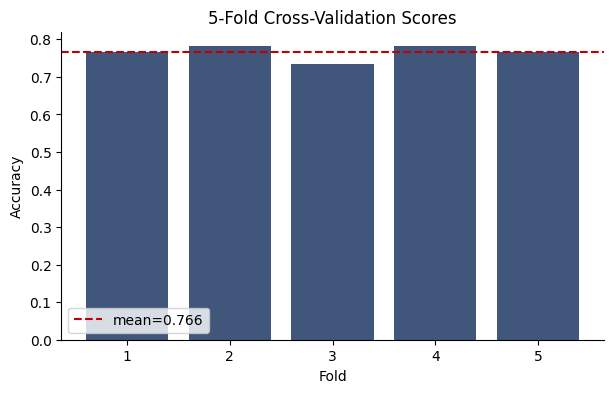

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(1, 6), scores, color='#1F3864', alpha=0.85)
ax.axhline(scores.mean(), color='#C00000', linestyle='--', label=f'mean={scores.mean():.3f}')
ax.set_xlabel('Fold')
ax.set_ylabel('Accuracy')
ax.set_title('5-Fold Cross-Validation Scores')
ax.legend()
plt.show()

**Observation:**
Fold scores vary, single-split validation could have landed on any one of these by chance. The mean across 5 folds is a more stable estimate than any single fold.

## Comparing Two Models with Cross-Validation

In [6]:
lr_scores = cross_val_score(LogisticRegression(), X_train_full_s, y_train_full, cv=kfold)
svm_scores = cross_val_score(SVC(kernel='rbf'), X_train_full_s, y_train_full, cv=kfold)

print(f'Logistic Regression: mean={lr_scores.mean():.4f}  std={lr_scores.std():.4f}')
print(f'SVM (RBF):            mean={svm_scores.mean():.4f}  std={svm_scores.std():.4f}')

Logistic Regression: mean=0.7656  std=0.0171
SVM (RBF):            mean=0.9062  std=0.0328


C:\Users\mohit\AppData\Local\Temp\ipykernel_20304\3505988109.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([lr_scores, svm_scores], labels=['Logistic Regression', 'SVM (RBF)'])


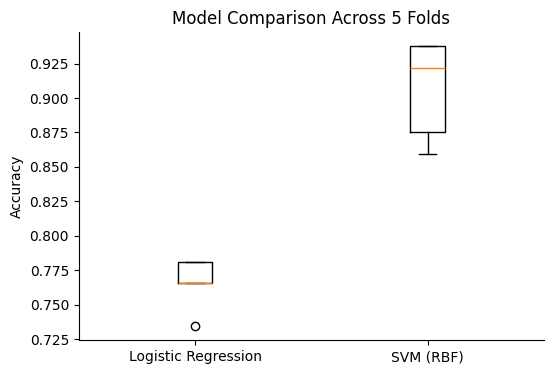

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.boxplot([lr_scores, svm_scores], labels=['Logistic Regression', 'SVM (RBF)'])
ax.set_ylabel('Accuracy')
ax.set_title('Model Comparison Across 5 Folds')
plt.show()

**Observation:**
Comparing both models on the exact same folds removes the risk that one model just happened to get an easier split than the other.

## Basic Hyperparameter Search

In [8]:
param_grid = {'C': [0.01, 0.1, 1, 10, 100]}

grid = GridSearchCV(SVC(kernel='rbf'), param_grid, cv=5)
grid.fit(X_train_full_s, y_train_full)

for C, mean_score in zip(param_grid['C'], grid.cv_results_['mean_test_score']):
    print(f'C={C:7.2f}  mean CV accuracy={mean_score:.4f}')

print(f'\nBest C: {grid.best_params_["C"]}  Best CV score: {grid.best_score_:.4f}')

C=   0.01  mean CV accuracy=0.7906
C=   0.10  mean CV accuracy=0.8469
C=   1.00  mean CV accuracy=0.9125
C=  10.00  mean CV accuracy=0.9156
C= 100.00  mean CV accuracy=0.8875

Best C: 10  Best CV score: 0.9156


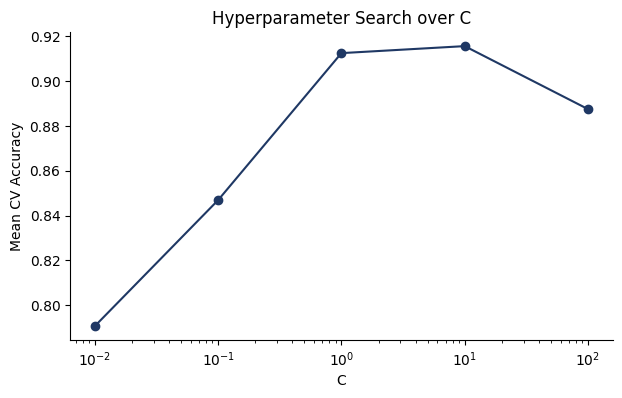

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(param_grid['C'], grid.cv_results_['mean_test_score'], 'o-', color='#1F3864')
ax.set_xscale('log')
ax.set_xlabel('C')
ax.set_ylabel('Mean CV Accuracy')
ax.set_title('Hyperparameter Search over C')
plt.show()

In [10]:
best_model = grid.best_estimator_
print(f'Final test accuracy with best C: {accuracy_score(y_test, best_model.predict(X_test_s)):.4f}')

Final test accuracy with best C: 0.9000


**Observation:**
GridSearchCV picks the C that scored best across the folds, not on the test set — the test set is only touched once, at the end, to report the final number.